<a href="https://colab.research.google.com/github/Kshejal20/Real-Estate-Price-Prediction-From-Scratch/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Libraries**


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


**1. LOAD DATA**

In [4]:
df = pd.read_csv("real_estate.csv")

**2. BASIC EDA**

In [5]:
print("Shape:", df.shape)

Shape: (414, 8)


In [6]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [7]:
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())



Data types:
No                                          int64
X1 transaction date                       float64
X2 house age                              float64
X3 distance to the nearest MRT station    float64
X4 number of convenience stores             int64
X5 latitude                               float64
X6 longitude                              float64
Y house price of unit area                float64
dtype: object

Missing values:
No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

Duplicate rows: 0


In [8]:
print("\nDescriptive statistics:")
print(df.describe().T)


Descriptive statistics:
                                        count         mean          std  \
No                                      414.0   207.500000   119.655756   
X1 transaction date                     414.0  2013.148971     0.281967   
X2 house age                            414.0    17.712560    11.392485   
X3 distance to the nearest MRT station  414.0  1083.885689  1262.109595   
X4 number of convenience stores         414.0     4.094203     2.945562   
X5 latitude                             414.0    24.969030     0.012410   
X6 longitude                            414.0   121.533361     0.015347   
Y house price of unit area              414.0    37.980193    13.606488   

                                               min          25%         50%  \
No                                         1.00000   104.250000   207.50000   
X1 transaction date                     2012.66700  2012.917000  2013.16700   
X2 house age                               0.00000     9.02500

**3. EDA VISUALIZATIONS**

3.1 Feature distributions

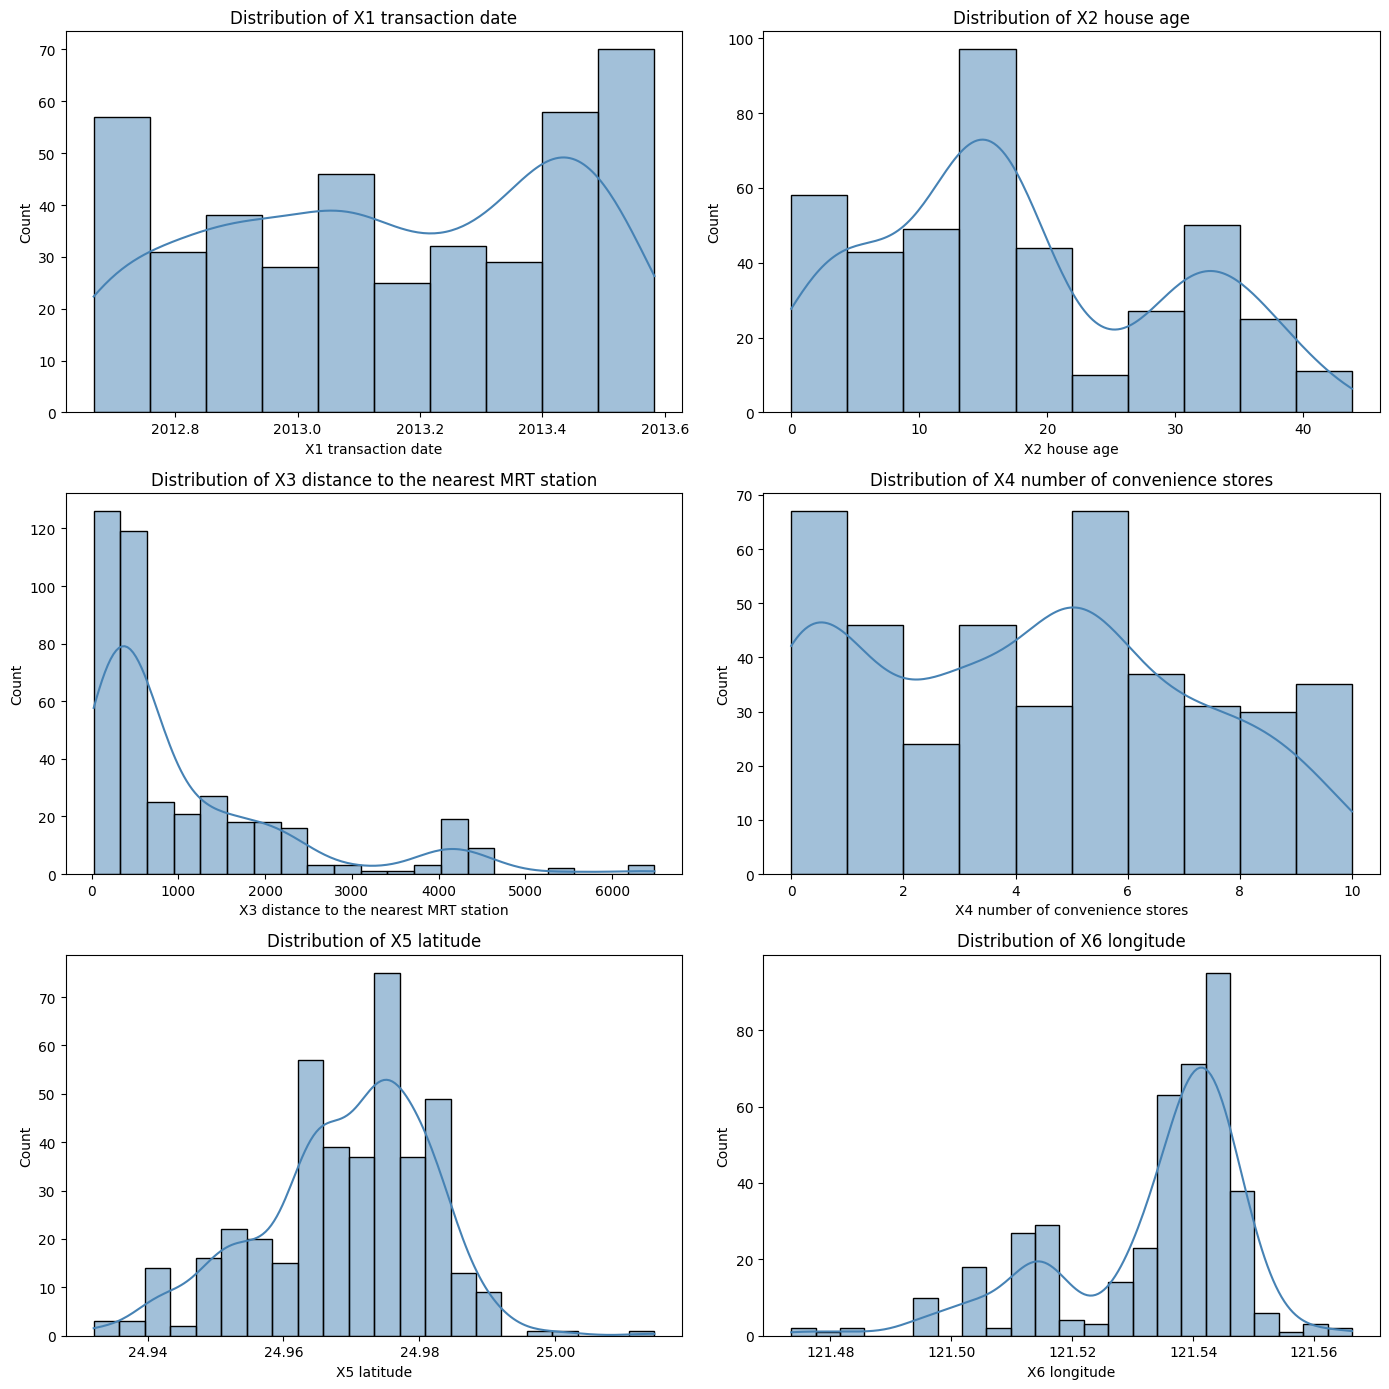

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

distribution_cols = [
    "X1 transaction date",
    "X2 house age",
    "X3 distance to the nearest MRT station",
    "X4 number of convenience stores",
    "X5 latitude",
    "X6 longitude"
]

for i, col in enumerate(distribution_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title("Distribution of " + col)

plt.tight_layout()
plt.show()


3.2 Correlation heatmap

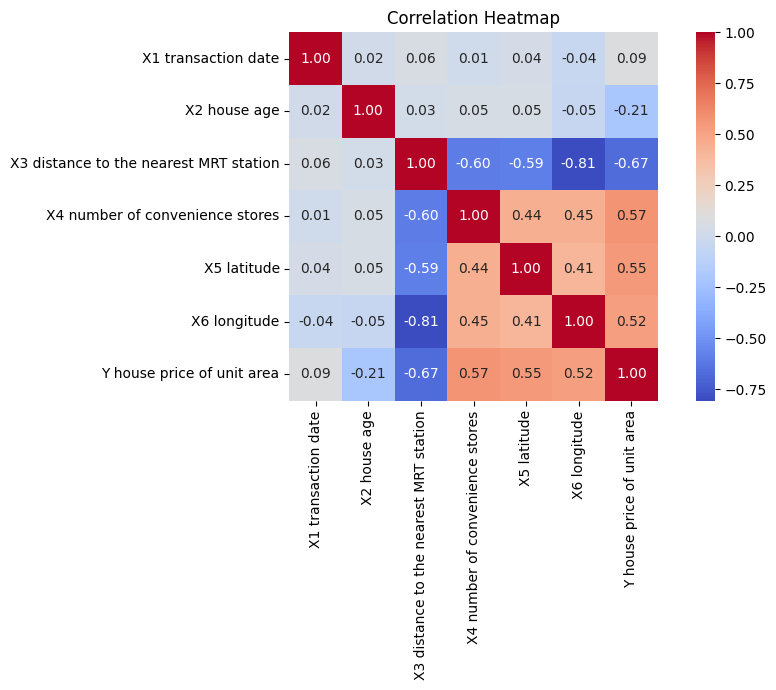

In [10]:
plt.figure(figsize=(10, 7))
corr_matrix = df.drop(columns=["No"]).corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

3.3 Boxplot for outlier detection


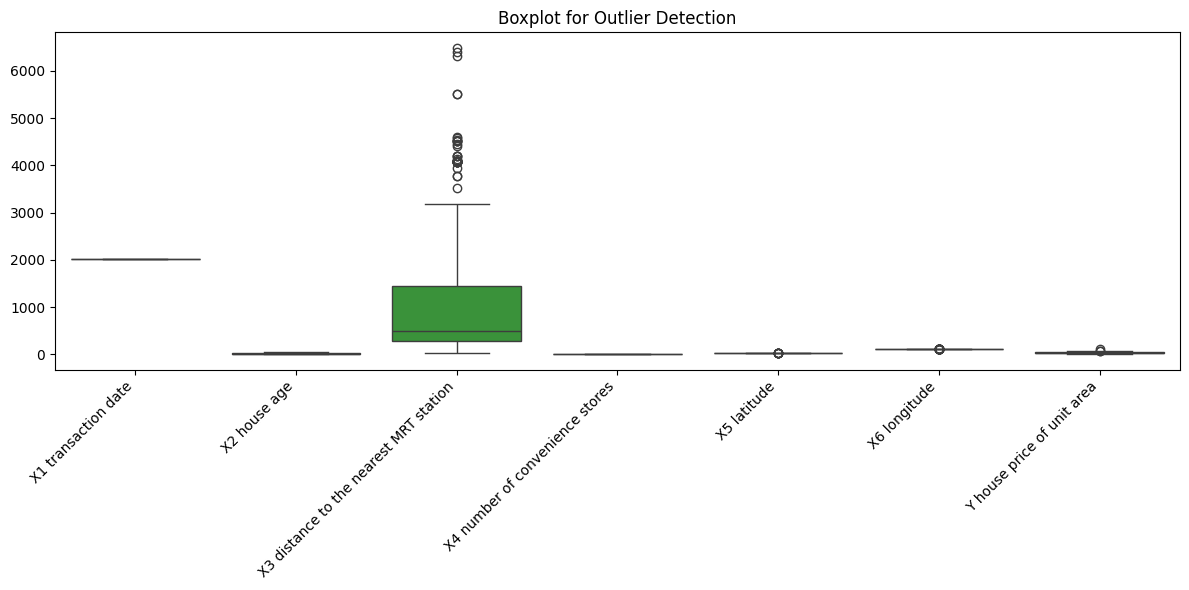

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=["No"]))
plt.xticks(rotation=45, ha="right")
plt.title("Boxplot for Outlier Detection")
plt.tight_layout()
plt.show()


3.4 Target distribution

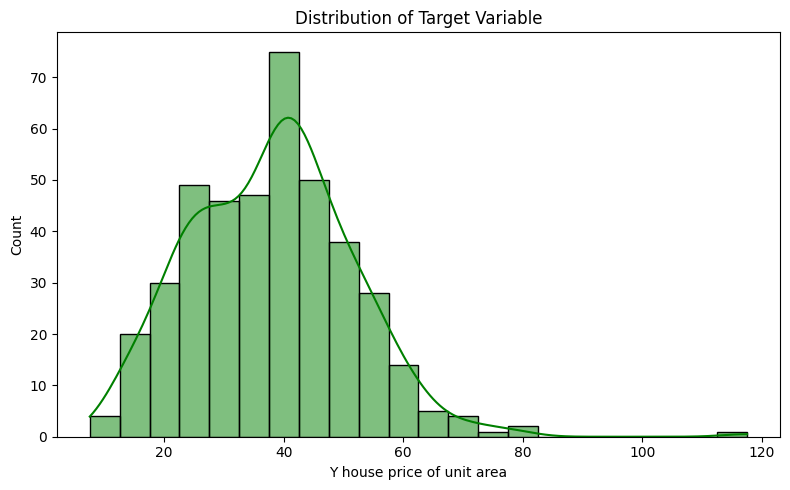

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Y house price of unit area"], kde=True, color="green")
plt.title("Distribution of Target Variable")
plt.tight_layout()
plt.show()

**4. PREPROCESSING**

In [13]:
# Drop identifier column
X = df.drop(columns=["No", "Y house price of unit area"])
y = df["Y house price of unit area"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**5. LINEAR REGRESSION FROM SCRATCH**

In [14]:
class ScratchLinearRegression:
    def __init__(self, learning_rate=0.01, n_iters=3000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.cost_history = []

    def _predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def _mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for i in range(self.n_iters):
            y_pred = self._predict(X)

            dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (2 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            cost = self._mse(y, y_pred)
            self.cost_history.append(cost)
        return self

    def predict(self, X):
        return self._predict(X)

In [15]:
# Train scratch model
scratch_model = ScratchLinearRegression(learning_rate=0.01, n_iters=3000)
scratch_model.fit(X_train_scaled, y_train.values)
scratch_predictions = scratch_model.predict(X_test_scaled)

**6. SCIKIT-LEARN LINEAR REGRESSION**

In [16]:
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_scaled, y_train)
sklearn_predictions = sklearn_model.predict(X_test_scaled)

**7. EVALUATION METRICS**

In [17]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))


def evaluate_model(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

scratch_results = evaluate_model(y_test, scratch_predictions)
sklearn_results = evaluate_model(y_test, sklearn_predictions)

results_df = pd.DataFrame(
    [scratch_results, sklearn_results],
    index=["Scratch NumPy", "Scikit-Learn"]
)

print("\nModel Comparison:")
print(results_df)


Model Comparison:
                    MAE        MSE      RMSE        R2
Scratch NumPy  5.305341  53.505457  7.314742  0.681059
Scikit-Learn   5.305356  53.505619  7.314754  0.681058


**8. VISUAL COMPARISON**

8.1 Cost function convergence

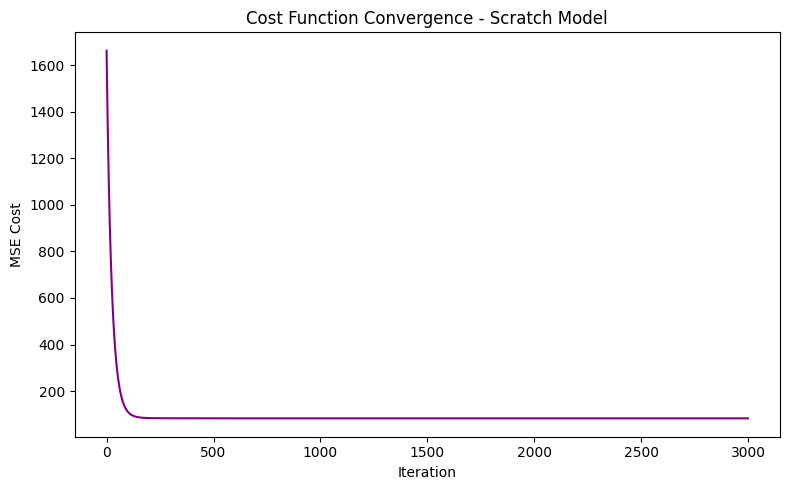

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(scratch_model.cost_history, color="purple")
plt.title("Cost Function Convergence - Scratch Model")
plt.xlabel("Iteration")
plt.ylabel("MSE Cost")
plt.tight_layout()
plt.show()


8.2 Actual vs Predicted - Scratch

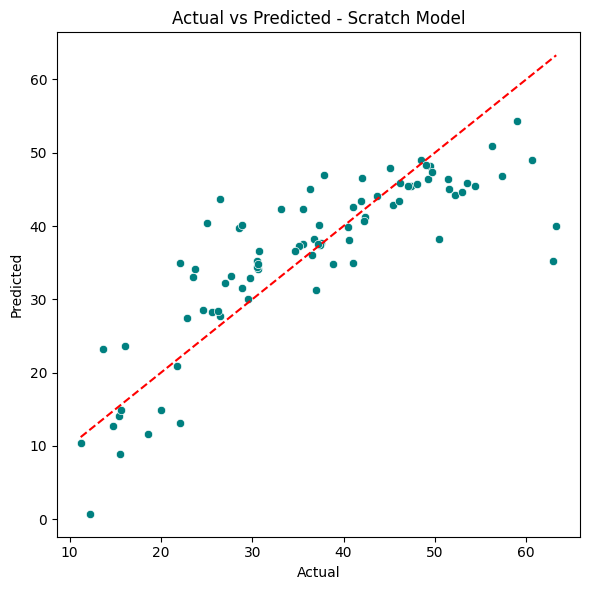

In [19]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=scratch_predictions, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Actual vs Predicted - Scratch Model")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

8.3 Actual vs Predicted - Scikit-Learn

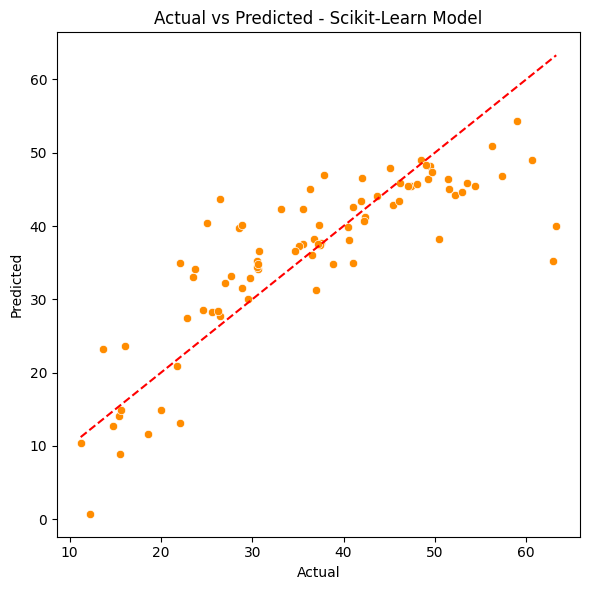

In [20]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=sklearn_predictions, color="darkorange")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Actual vs Predicted - Scikit-Learn Model")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()


8.4 Residual analysis - Scratch

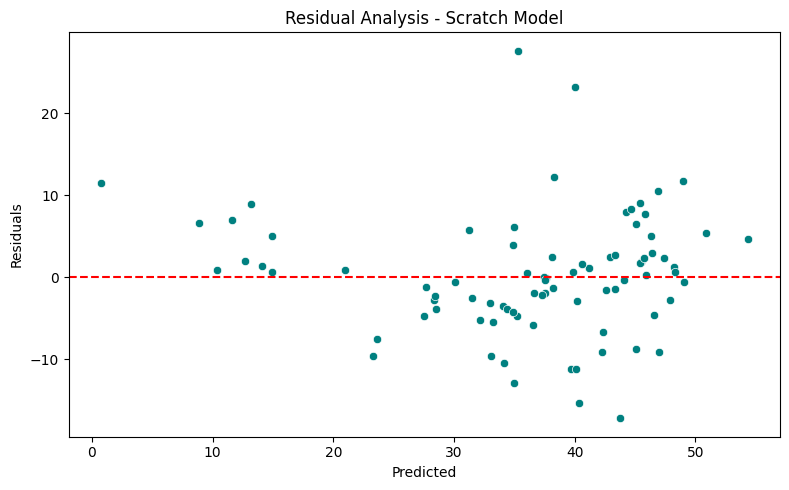

In [21]:
scratch_residuals = y_test.values - scratch_predictions

plt.figure(figsize=(8, 5))
sns.scatterplot(x=scratch_predictions, y=scratch_residuals, color="teal")
plt.axhline(0, color="red", linestyle="--")
plt.title("Residual Analysis - Scratch Model")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

8.5 Residual distribution - Scratch


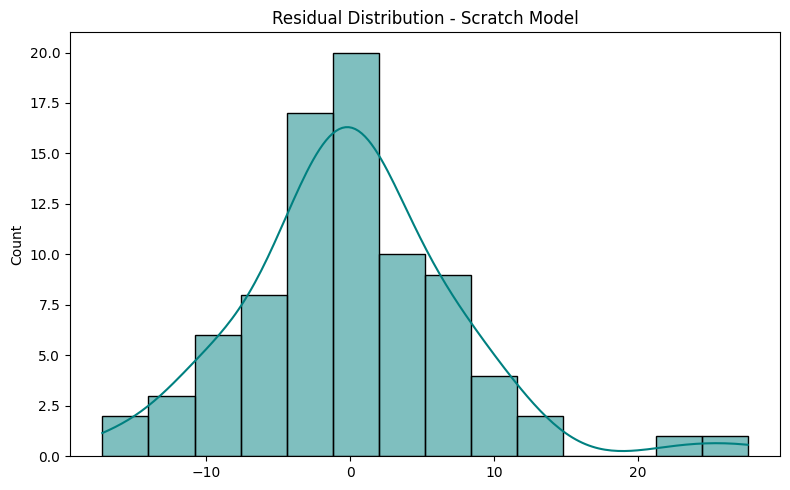

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(scratch_residuals, kde=True, color="teal")
plt.title("Residual Distribution - Scratch Model")
plt.tight_layout()
plt.show()

**9. FINAL OUTPUTS**

In [23]:
print("\nScratch model weights:")
print(scratch_model.weights)

print("\nScratch model bias:")
print(scratch_model.bias)

comparison_sample = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Scratch Prediction": scratch_predictions[:10],
    "Sklearn Prediction": sklearn_predictions[:10]
})

print("\nSample predictions:")
print(comparison_sample)


Scratch model weights:
[ 1.52962311 -3.06269603 -5.78673892  3.21891657  2.85514995 -0.44087566]

Scratch model bias:
38.39154078549871

Sample predictions:
   Actual  Scratch Prediction  Sklearn Prediction
0    45.1           47.886201           47.886254
1    42.3           41.163993           41.164046
2    52.2           44.272841           44.273014
3    37.3           40.197419           40.197615
4    22.8           27.513223           27.513265
5    36.3           45.109546           45.109531
6    53.0           44.632963           44.632933
7    51.4           46.363483           46.363462
8    16.1           23.620492           23.620631
9    59.0           54.334461           54.334449
